In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [29]:
obesity = pd.read_csv('data/obesity.csv')
print(obesity.head())
print('==========================================================================')
print(obesity .info())
print('==========================================================================')


   Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0   56    Male  173.575262  71.982051  23.891783                      4   
1   69    Male  164.127306  89.959256  33.395209                      2   
2   46  Female  168.072202  72.930629  25.817737                      4   
3   32    Male  168.459633  84.886912  29.912247                      3   
4   60    Male  183.568568  69.038945  20.487903                      3   

  ObesityCategory  
0   Normal weight  
1           Obese  
2      Overweight  
3      Overweight  
4   Normal weight  
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender                 1000 non-null   str    
 2   Height                 1000 non-null   float64
 3   Weight                 1000 non-null   float64
 4   BMI               

In [30]:
# investigating missing data
obesity.isnull().sum()

Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64

ObesityCategory
Normal weight    371
Overweight       295
Obese            191
Underweight      143
Name: count, dtype: int64


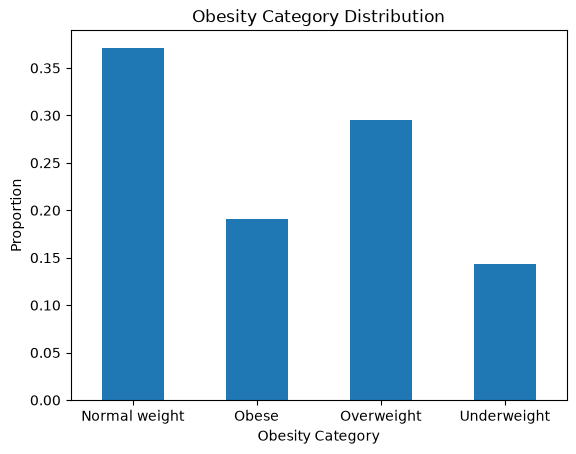

In [31]:
print(obesity.value_counts('ObesityCategory', dropna=False))

obesity['ObesityCategory'].value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title('Obesity Category Distribution')
plt.xlabel('Obesity Category')
plt.ylabel('Proportion')
plt.xticks([0, 1, 2, 3], ['Normal weight','Obese','Overweight','Underweight'], rotation=0)
plt.show()

In [36]:
X = obesity.drop(columns=['ObesityCategory'])
y = obesity['ObesityCategory']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print('==========================================================================')
print(y_train.head())
print('==========================================================================')
print(X_train.head())

(750, 6) (250, 6) (750,) (250,)
796         Obese
168         Obese
620         Obese
861    Overweight
526    Overweight
Name: ObesityCategory, dtype: str
     Age  Gender      Height     Weight        BMI  PhysicalActivityLevel
796   33  Female  157.303100  80.029748  32.342746                      3
168   57  Female  155.738745  77.000882  31.746976                      4
620   33  Female  159.233391  85.892208  33.875482                      3
861   53  Female  166.778604  78.849227  28.347631                      2
526   24    Male  162.004611  76.308177  29.074773                      4


InvalidIndexError: (slice(None, None, None), 0)

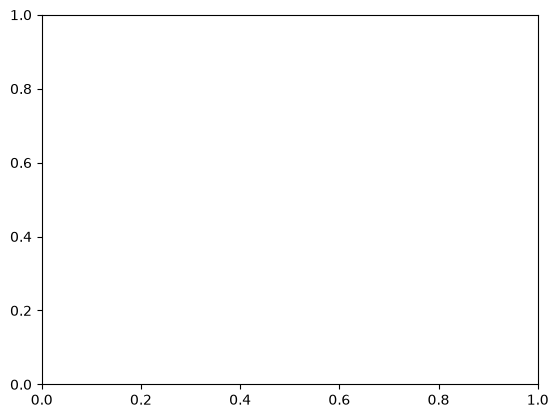

In [33]:
fig, ax = plt.subplots()
for label, color in enumerate(['blue', 'orange', 'red', 'purple']):
    ax.scatter(X_train[y_train == label][:, 0], X_train[y_train == label][:, 1], c=color, label=label,
               alpha=0.6, edgecolors='black', s = 60)
ax.scatter(X_test[:, 0], X_test[:, 1], c='green', label='test',
               alpha=0.8, edgecolors='black', s = 70)
    
ax.legend(title = 'Class')
ax.set_title('Synthetic Binary Classification Dataset')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True)